In [2]:
from ctypes import kind

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('./assets/cleaned_5G_smartphone.csv')

In [21]:
df

,pos,brand,model,price,rating,Dual Sim,3G,4G,5G,VoLTE,...,pixel_height,os,is_memory_card_supported,max_card_gb,primary_rear_mp,primary_front_mp,num_rear_cameras,num_front_cameras,processor_brand,processor_model
0,0,Samsung,Galaxy S25 Ultra,118998,4.15,True,True,True,True,True,...,3120,Android,False,NaN,200,12,4,1,Snapdragon,8 elite for galaxy
1,1,OnePlus,Nord 6,38999,4.60,True,True,True,True,True,...,2772,Android,False,NaN,50,32,2,1,Snapdragon,8s gen4
2,2,Samsung,Galaxy S25 FE,44999,4.70,True,True,True,True,True,...,2340,Android,False,NaN,50,12,3,1,Exynos,2400
3,3,Vivo,T5x 5G,18999,4.10,True,True,True,True,True,...,2344,Android,False,NaN,50,32,2,1,Dimensity,7400 turbo
4,4,Infinix,Note 60 Pro 5G,31999,4.75,True,True,True,True,True,...,2644,Android,True,1024.0,50,13,2,1,Snapdragon,7s gen4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
897,897,Tecno,Spark 10 5G,13800,4.55,True,True,True,True,True,...,1612,Android,True,1024.0,50,8,2,1,Dimensity,6020
898,898,Xiaomi,Redmi Note 12,18499,4.20,True,True,True,True,True,...,2400,Android,True,1024.0,48,13,3,1,Snapdragon,4 gen 1
899,899,Realme,11,18999,4.75,True,True,True,True,True,...,2400,Android,True,1024.0,108,16,2,1,Dimensity,6100 plus
900,900,Motorola,Razr 40 Ultra,59990,4.20,True,True,True,True,True,...,2640,iOS,False,NaN,13,32,2,1,Snapdragon,8+ gen1


In [7]:
df['os'].value_counts()

os
Android v15      356
Android v14      242
Android v16      146
Android v13       69
Android v12       23
iOS v18           14
iOS v26           12
iOS v17            6
Android v11        6
iOS v26.3          2
iOS v16            2
iOS v14.0          2
Android v10.0      2
iOS v15            1
Android 15 Go      1
Android v10        1
Name: count, dtype: int64

In [11]:
df['os'] = df['os'].apply(lambda x: "Android" if "Android" in str(x) else "iOS")

In [19]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 902 entries, 0 to 901
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   pos                       902 non-null    int64  
 1   brand                     902 non-null    str    
 2   model                     902 non-null    str    
 3   price                     902 non-null    int64  
 4   rating                    902 non-null    float64
 5   Dual Sim                  902 non-null    bool   
 6   3G                        902 non-null    bool   
 7   4G                        902 non-null    bool   
 8   5G                        902 non-null    bool   
 9   VoLTE                     902 non-null    bool   
 10  Vo5G                      902 non-null    bool   
 11  Wi-Fi                     902 non-null    bool   
 12  NFC                       902 non-null    bool   
 13  IR Blaster                902 non-null    bool   
 14  processor_core       

In [20]:
df.isnull().sum()

pos                           0
brand                         0
model                         0
price                         0
rating                        0
Dual Sim                      0
3G                            0
4G                            0
5G                            0
VoLTE                         0
Vo5G                          0
Wi-Fi                         0
NFC                           0
IR Blaster                    0
processor_core                0
processor_speed_in_GHz       37
Ram                           0
storage                       0
battery_capacity              0
is_fast_charging              0
fast_charging_capacity       52
display_size                  0
display_refresh_rate         38
camera_notch_type             8
pixel_width                   0
pixel_height                  0
os                            0
is_memory_card_supported      0
max_card_gb                 610
primary_rear_mp               0
primary_front_mp              0
num_rear

## brand column univariate analysis
- Realme > Vivo = Samsung are the three dominating companies

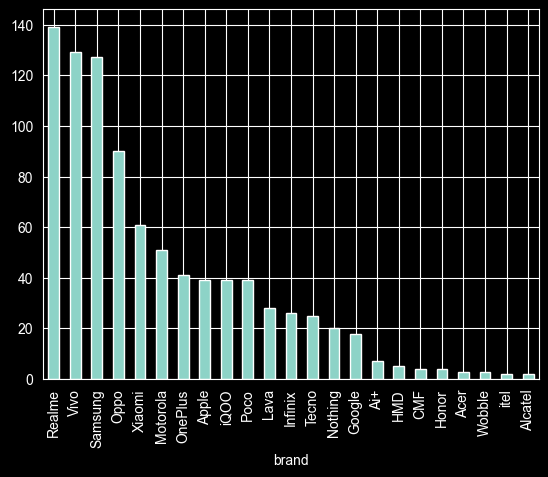

In [29]:
df['brand'].value_counts().plot(kind='bar')
plt.savefig('./plots/univariate_analysis/brand/bar_plot.png')


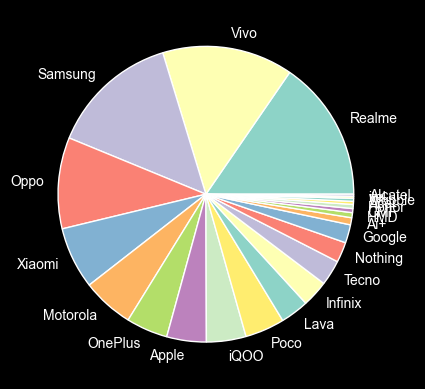

In [30]:
df['brand'].value_counts().plot(kind='pie')
plt.savefig('./plots/univariate_analysis/brand/pie_plot.png')

# price column univariate analysis
- budget phones are dominating (<100000)
- outlier exists `(mean is too high)`
- highly skewed ` (2.6280120605206196)`

In [33]:
df['price'].describe()

count       902.000000
mean      36032.215078
std       31932.852245
min        7499.000000
25%       16999.000000
50%       24999.000000
75%       39968.250000
max      222990.000000
Name: price, dtype: float64

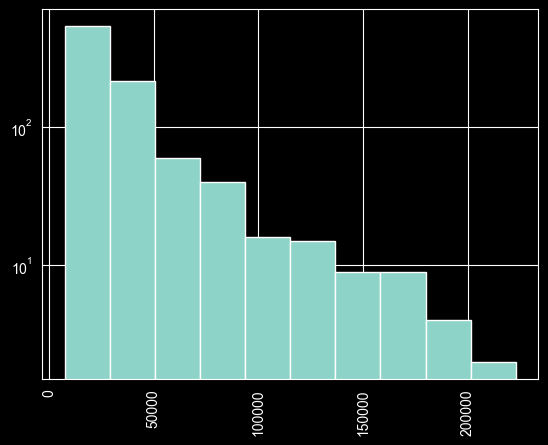

In [41]:
plt.hist(df['price'],bins=10,log=True)
plt.xticks(rotation=90)
plt.savefig('./plots/univariate_analysis/price/hist_plot.png')

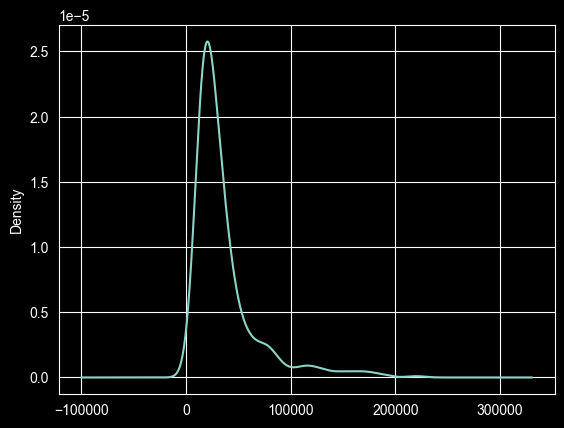

In [43]:
df['price'].plot(kind='kde')
plt.savefig('./plots/univariate_analysis/price/kde_plot.png')

In [166]:
df['price'].skew()

np.float64(2.6280120605206196)

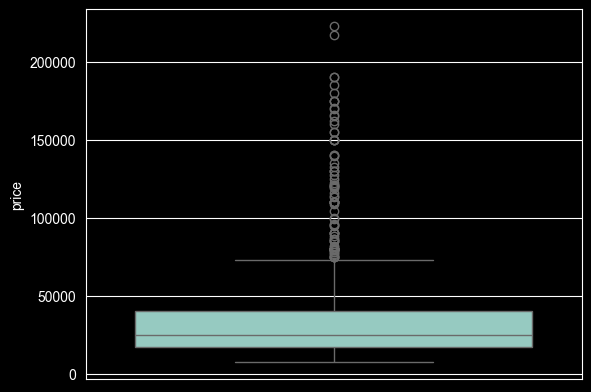

In [168]:
sns.boxplot(df['price'])
plt.savefig('./plots/univariate_analysis/price/box_plot.png')

In [170]:
df[df['price'] > 200000]

,Unnamed: 0,pos,brand,model,price,rating,Dual Sim,3G,4G,5G,...,pixel_height,os,is_memory_card_supported,max_card_gb,primary_rear_mp,primary_front_mp,num_rear_cameras,num_front_cameras,processor_brand,processor_model
414,414,414,Apple,iPhone 17 Pro Max,222990,4.0,True,True,True,True,...,2868,iOS,False,NaN,48,18,3,1,Apple,A19 pro
506,506,506,Samsung,Galaxy Z Fold 7,216999,4.6,True,True,True,True,...,2184,Android,False,NaN,200,10,3,2,Snapdragon,8 elite for galaxy


In [171]:
df.drop(columns=['Unnamed: 0'],inplace=True)

# dual sim univariate analysis
- Except one phone all phones have dual sim

<Axes: xlabel='Dual Sim'>

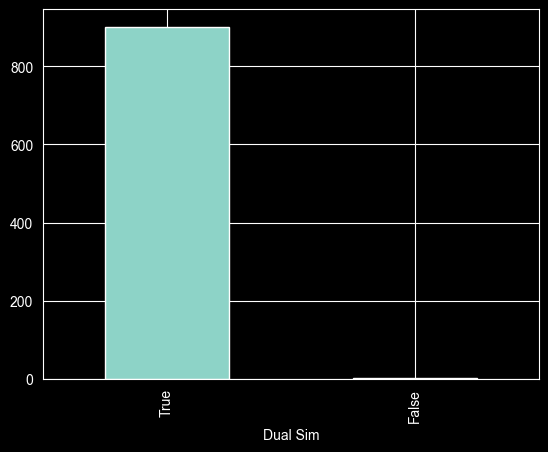

In [45]:
df['Dual Sim'].value_counts().plot(kind='bar')

## rating univariate analysis

In [176]:
df['rating'].isna().sum()

np.int64(0)

In [173]:
df['rating'].describe()

count    902.000000
mean       4.375831
std        0.231444
min        3.900000
25%        4.150000
50%        4.350000
75%        4.600000
max        4.750000
Name: rating, dtype: float64

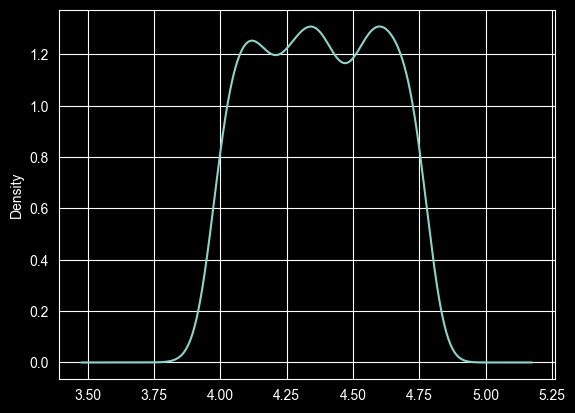

In [178]:
df['rating'].plot(kind='kde')
plt.savefig('./plots/univariate_analysis/rating/kde_plot.png')

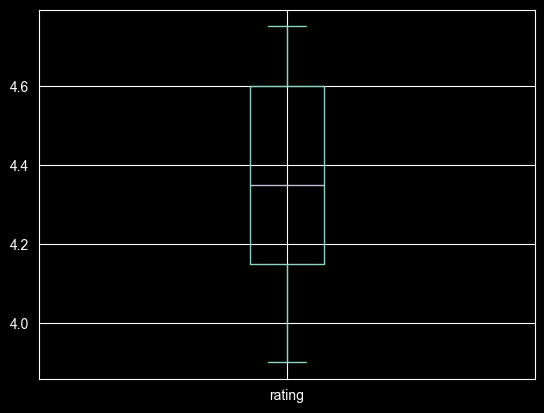

In [175]:
df['rating'].plot(kind='box')
plt.savefig('./plots/univariate_analysis/rating/box_plot.png')

# 3G univariate analysis
- all phones have 3G

# 4G univariate analysis
- all phones have 4G

# 5G univariate analysis
- all phones have 5G

# VoLTE univariate analysis
- Almost all phones have VoLTE except some Oppo, Realme and one Motorola phone

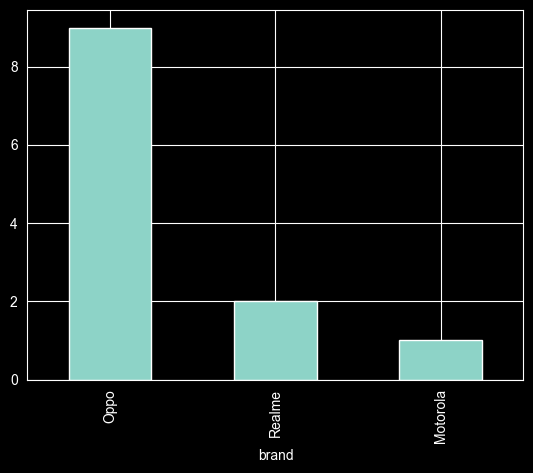

In [62]:
df[df['VoLTE'] == False]['brand'].value_counts().plot(kind='bar')
plt.savefig('./plots/univariate_analysis/VoLTE/bar_plot.png')

# Wi-Fi univariate analysis
- Every phone has Wi-Fi

<Axes: >

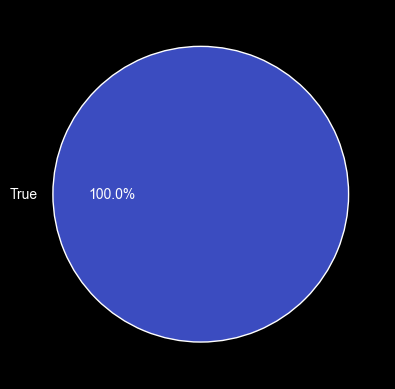

In [179]:
df['Wi-Fi'].value_counts().plot(kind='pie', autopct='%1.1f%%', cmap='coolwarm')

# NFC univariate analysis
- Half of the phones have NFC

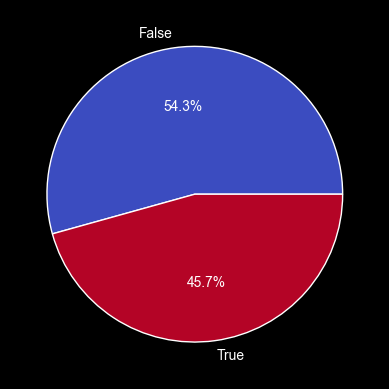

In [71]:
df['NFC'].value_counts().plot(kind='pie',autopct='%1.1f%%',cmap='coolwarm')
plt.savefig('./plots/univariate_analysis/NFC/pie_plot.png')

# IR Blaster univariate analysis
- Mostly Chinese phones have ir blaster

In [181]:
df[df['IR Blaster']==True]['brand'].value_counts()

brand
Vivo       55
Xiaomi     51
Oppo       42
Realme     38
OnePlus    30
Poco       30
iQOO       24
Infinix    20
Tecno      19
Honor       2
Lava        1
itel        1
Name: count, dtype: int64

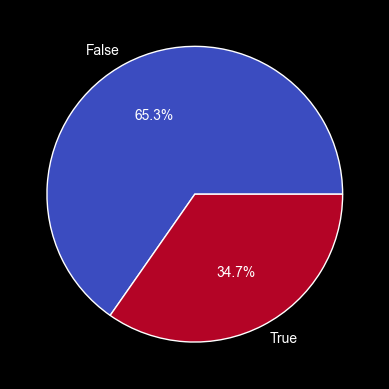

In [76]:
df['IR Blaster'].value_counts().plot(kind='pie',autopct='%1.1f%%',cmap='coolwarm')
plt.savefig('./plots/univariate_analysis/IR_Blaster/pie_plot.png')

## processor_brand univariate analysis
- Most of the phones in the market have Dimensity, Snapdragon or Exynos processors

In [188]:
df[df['processor_brand'] == 'Other'].index

Index([83, 99, 111, 195, 203, 306, 333, 377, 407, 408, 556, 634, 656, 673, 761,
       770],
      dtype='int64')

In [190]:
df.loc[[83, 99, 111, 195, 203, 306, 333, 377, 407, 408, 556, 634, 656, 673, 761,
       770],'processor_brand'] = 'Google'

In [191]:
df['processor_brand'].value_counts()

processor_brand
Dimensity     449
Snapdragon    320
Exynos         57
Apple          39
Unisoc         19
Google         18
Name: count, dtype: int64

<Axes: >

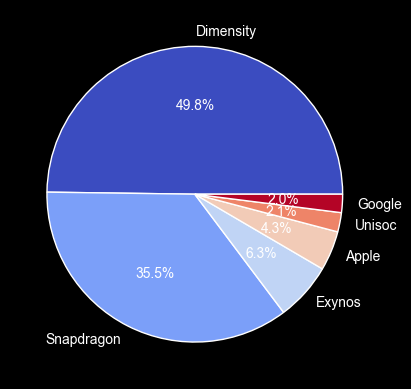

In [193]:
df['processor_brand'].value_counts().plot(kind='pie',autopct='%1.1f%%',cmap='coolwarm')

# processor_core univariate analysis
- 93.8% of the phones have 8 core processor

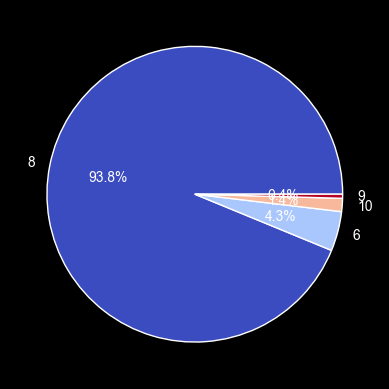

In [79]:
df['processor_core'].value_counts().plot(kind='pie',autopct='%1.1f%%',cmap='coolwarm')
plt.savefig('./plots/univariate_analysis/processor_core/pie_plot.png')

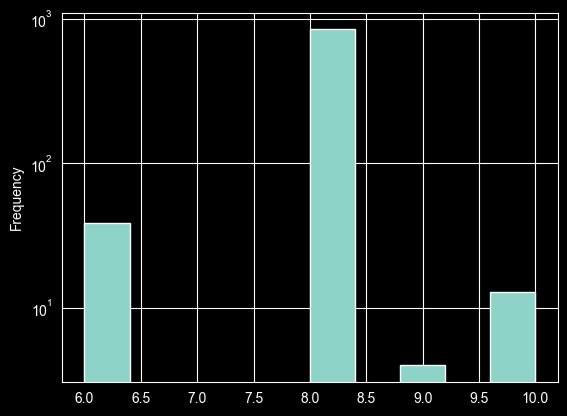

In [82]:
df['processor_core'].plot(kind='hist',log=True)
plt.savefig('./plots/univariate_analysis/processor_core/hist_plot.png')

# processor_speed_in_GHz univariate analysis
- majority of the processor has speed between 2.25 - 2.5 GHz
- weird anomaly between 3-3.5 GHz speed
- there are 53 outliers `(speed > 3.9 GHz)`

In [84]:
df['processor_speed_in_GHz'].describe()

count    865.000000
mean       2.750486
std        0.563318
min        2.000000
25%        2.400000
50%        2.500000
75%        3.000000
max        4.740000
Name: processor_speed_in_GHz, dtype: float64

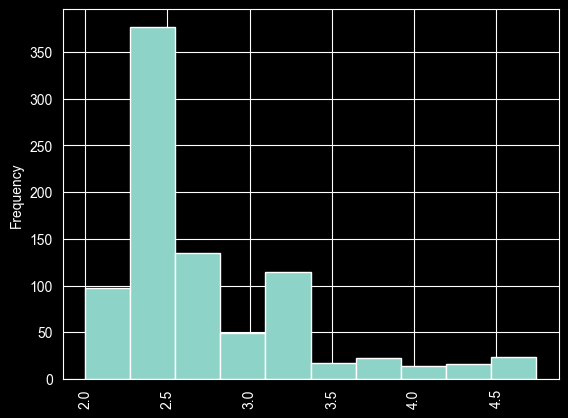

In [90]:
df['processor_speed_in_GHz'].plot(kind='hist')
plt.xticks(rotation=90)
plt.savefig('./plots/univariate_analysis/processor_speed_in_GHz/hist_plot.png')

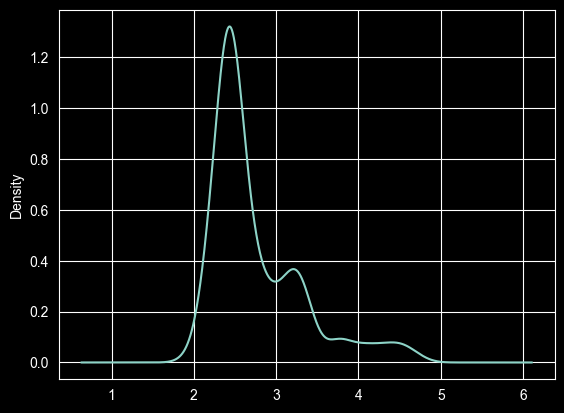

In [141]:
df['processor_speed_in_GHz'].plot(kind='kde')
plt.savefig('./plots/univariate_analysis/processor_speed_in_GHz/kde_plot.png')

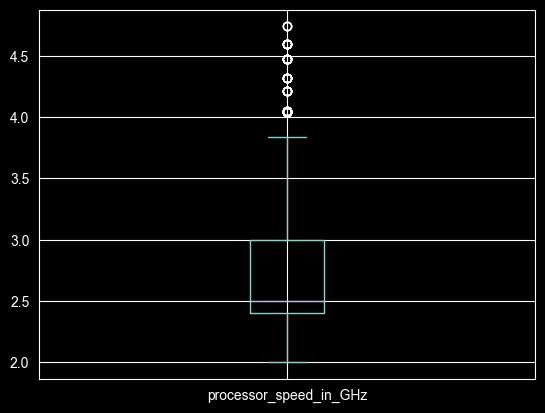

In [93]:
df['processor_speed_in_GHz'].plot(kind='box')
plt.savefig('./plots/univariate_analysis/processor_speed_in_GHz/box_plot.png')

### Fixing some missing and misplaced values in the os and battery_capacity columns

In [137]:
df[(df['processor_speed_in_GHz'] >= 3.0) & (df['processor_speed_in_GHz'] <= 3.5) ].groupby(['brand','os'])

KeyError: ('Vivo', 'iOS')

In [136]:
df.loc[[713],'os'] = "Android"

In [139]:
df.to_csv('../filled_osnNA_cleaned_5G_smartphone.csv')

In [195]:
df = pd.read_csv('./assets/final.csv')

In [162]:
df[df['battery_capacity'].isna()]

,Unnamed: 0,pos,brand,model,price,rating,Dual Sim,3G,4G,5G,...,pixel_height,os,is_memory_card_supported,max_card_gb,primary_rear_mp,primary_front_mp,num_rear_cameras,num_front_cameras,processor_brand,processor_model
678,678,678,Apple,iPhone 12 Pro Max,119900,4.6,True,True,True,True,...,2778,iOS,False,NaN,12,12,3,1,Apple,A14
731,731,731,Apple,iPhone 12 Pro,109900,4.0,True,True,True,True,...,2532,iOS,False,NaN,12,12,3,1,Apple,A14


In [156]:
df.loc[[678,731],'battery_capacity']

678   NaN
731   NaN
Name: battery_capacity, dtype: float64

In [194]:
df.to_csv('./assets/final.csv',index=False)

In [196]:
df

,pos,brand,model,price,rating,Dual Sim,3G,4G,5G,VoLTE,...,pixel_height,os,is_memory_card_supported,max_card_gb,primary_rear_mp,primary_front_mp,num_rear_cameras,num_front_cameras,processor_brand,processor_model
0,0,Samsung,Galaxy S25 Ultra,118998,4.15,True,True,True,True,True,...,3120,Android,False,NaN,200,12,4,1,Snapdragon,8 elite for galaxy
1,1,OnePlus,Nord 6,38999,4.60,True,True,True,True,True,...,2772,Android,False,NaN,50,32,2,1,Snapdragon,8s gen4
2,2,Samsung,Galaxy S25 FE,44999,4.70,True,True,True,True,True,...,2340,Android,False,NaN,50,12,3,1,Exynos,2400
3,3,Vivo,T5x 5G,18999,4.10,True,True,True,True,True,...,2344,Android,False,NaN,50,32,2,1,Dimensity,7400 turbo
4,4,Infinix,Note 60 Pro 5G,31999,4.75,True,True,True,True,True,...,2644,Android,True,1024.0,50,13,2,1,Snapdragon,7s gen4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
897,897,Tecno,Spark 10 5G,13800,4.55,True,True,True,True,True,...,1612,Android,True,1024.0,50,8,2,1,Dimensity,6020
898,898,Xiaomi,Redmi Note 12,18499,4.20,True,True,True,True,True,...,2400,Android,True,1024.0,48,13,3,1,Snapdragon,4 gen 1
899,899,Realme,11,18999,4.75,True,True,True,True,True,...,2400,Android,True,1024.0,108,16,2,1,Dimensity,6100 plus
900,900,Motorola,Razr 40 Ultra,59990,4.20,True,True,True,True,True,...,2640,Android,False,NaN,13,32,2,1,Snapdragon,8+ gen1


### Ram univariate analysis
- majority of the phones have 8 gb ram

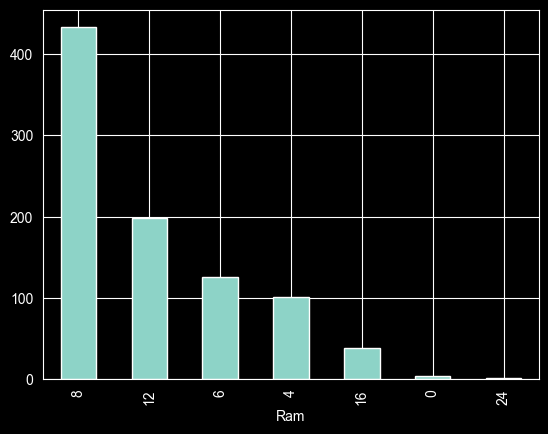

In [199]:
df['Ram'].value_counts().plot(kind='bar')
plt.savefig('./plots/univariate_analysis/Ram/bar_plot.png')

### storage univariate analysis
- most phones have 128GB or 256GB storage

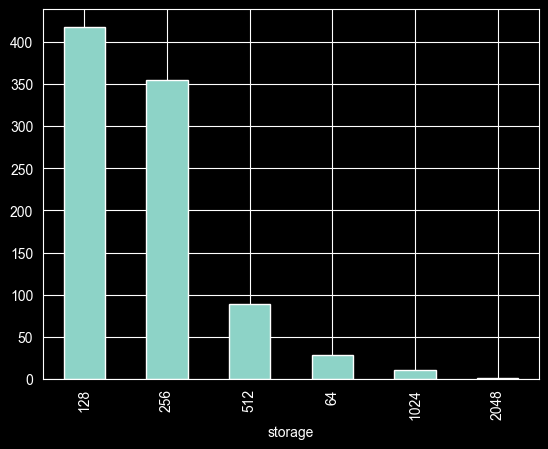

In [212]:
df['storage'].value_counts().plot(kind='bar')
plt.savefig('./plots/univariate_analysis/storage/bar_plot.png')

## battery_capacity univariate analysis
- most phones have around 5000mAh battery capacity
- Outlier exists! 9 chinese phone with exceptionally high battery capacity ` > 8000 mAh`

In [213]:
df['battery_capacity'].describe()

count      900.000000
mean      5598.230000
std        984.900844
min       3149.000000
25%       5000.000000
50%       5320.000000
75%       6200.000000
max      10001.000000
Name: battery_capacity, dtype: float64

<Axes: ylabel='Density'>

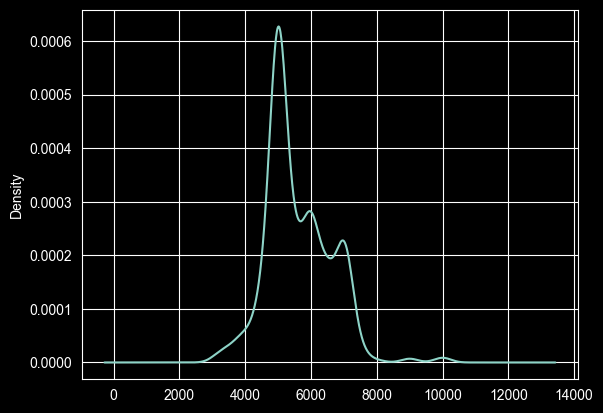

In [214]:
df['battery_capacity'].plot(kind='kde')

<Axes: ylabel='Frequency'>

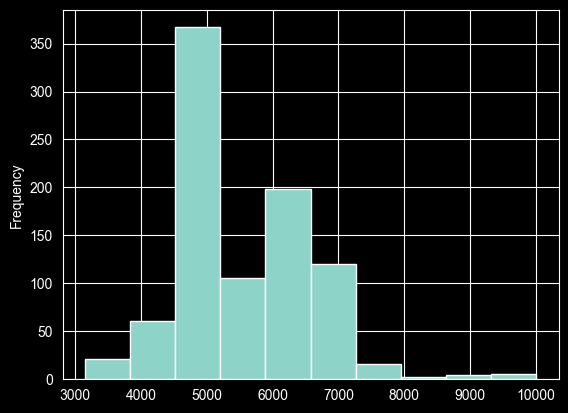

In [215]:
df['battery_capacity'].plot(kind='hist')

<Axes: >

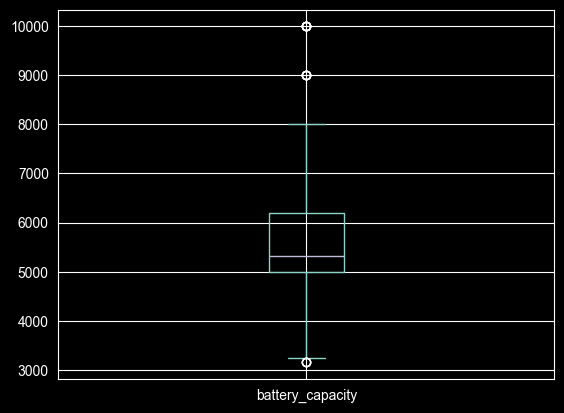

In [216]:
df['battery_capacity'].plot(kind='box')

In [220]:
df[df['battery_capacity'] > 8000][['brand','model','battery_capacity']]

,brand,model,battery_capacity
1,OnePlus,Nord 6,9000.0
8,OnePlus,Nord 6 5G,9000.0
19,Realme,P4 Power 5G,10001.0
120,Realme,Narzo Power 5G,10001.0
124,Poco,X8 Pro Max,9000.0
166,Realme,P4 Power 5G,10001.0
206,Realme,Narzo Power 5G,10001.0
294,Poco,X8 Pro Max 5G,9000.0
342,Realme,P4 Power 5G,10001.0


## is_fast_charging
- Except 1 every phone has fast charging ` index 539`

In [221]:
df['is_fast_charging'].value_counts()

is_fast_charging
True     901
False      1
Name: count, dtype: int64

In [222]:
df[df['is_fast_charging'] == False]

,pos,brand,model,price,rating,Dual Sim,3G,4G,5G,VoLTE,...,pixel_height,os,is_memory_card_supported,max_card_gb,primary_rear_mp,primary_front_mp,num_rear_cameras,num_front_cameras,processor_brand,processor_model
539,539,Lava,Blaze AMOLED 2,14999,4.75,True,True,True,True,True,...,2400,Android,True,1024.0,50,8,2,1,Dimensity,7060


## fast_charging_capacity
- majority of the phones have fast_charging_capacity around either 50W or 80W

In [223]:
df['fast_charging_capacity'].describe()

count    850.000000
mean      54.335294
std       28.467688
min        0.000000
25%       33.000000
50%       45.000000
75%       80.000000
max      125.000000
Name: fast_charging_capacity, dtype: float64

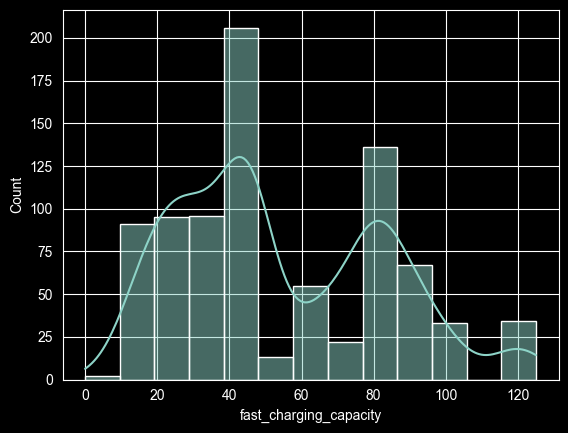

In [227]:
sns.histplot(data=df,x='fast_charging_capacity',kde=True)
plt.savefig('./plots/univariate_analysis/fast_charging_capacity/hist_plot.png')

<Axes: >

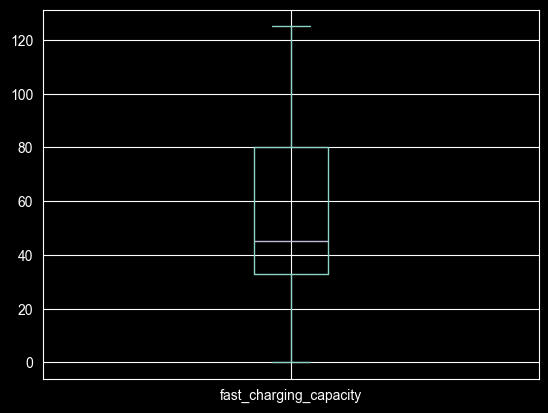

In [228]:
df['fast_charging_capacity'].plot(kind='box')

## display_refresh_rate
- Majority phones have 120 Hz refresh rate

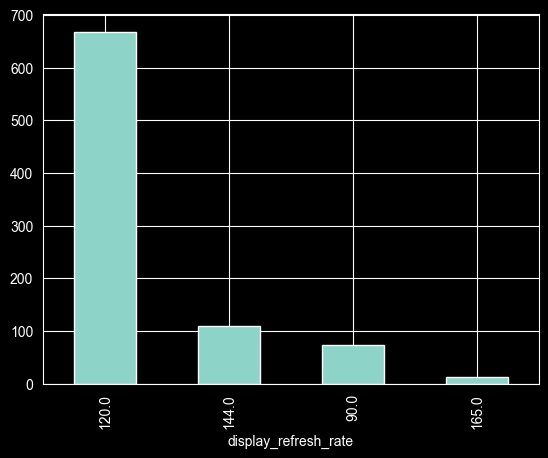

In [231]:
df['display_refresh_rate'].value_counts().plot(kind='bar')
plt.savefig('./plots/univariate_analysis/display_refresh_rate/bar_plot.png')

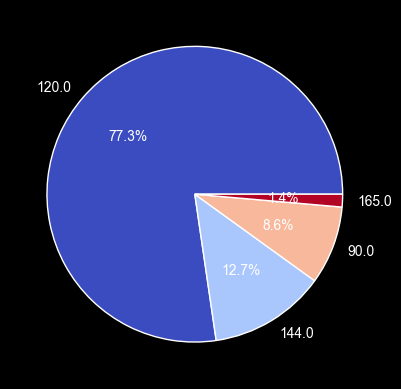

In [237]:
df['display_refresh_rate'].value_counts().plot(kind='pie',autopct='%1.1f%%',cmap='coolwarm')
plt.savefig('./plots/univariate_analysis/display_refresh_rate/pie_plot.png')

## display_size

In [233]:
df['display_size'].describe()

count    902.000000
mean       6.702151
std        0.205323
min        6.100000
25%        6.670000
50%        6.710000
75%        6.780000
max        8.030000
Name: display_size, dtype: float64

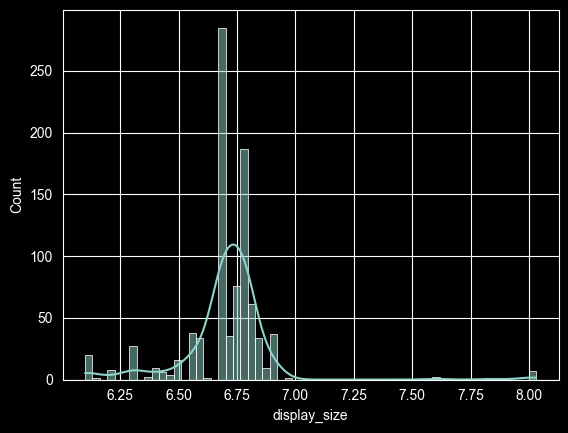

In [235]:
sns.histplot(data=df,x='display_size',kde=True)
plt.savefig('./plots/univariate_analysis/display_size/hist_plot.png')

## pixel_width
- outlier exists! Some phones are flip phones or foldable phones and some phones have pixel width and height swapped
- foldable phones index: [437, 506, 656, 669, 688, 713, 714, 751, 761, 843]
- swapped values index: [7, 14, 44, 72, 108, 130, 205, 343, 398, 757, 817, 826]

In [239]:
df['pixel_width'].describe()

count     902.000000
mean     1105.240576
std       279.176605
min       720.000000
25%      1080.000000
50%      1080.000000
75%      1252.000000
max      2790.000000
Name: pixel_width, dtype: float64

<Axes: xlabel='pixel_width', ylabel='Count'>

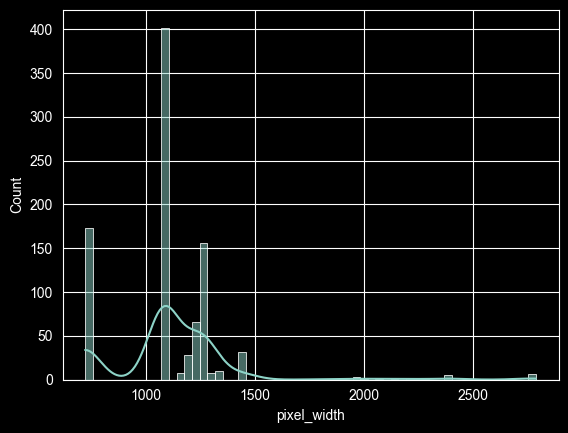

In [242]:
sns.histplot(data=df,x='pixel_width',kde=True)

<Axes: >

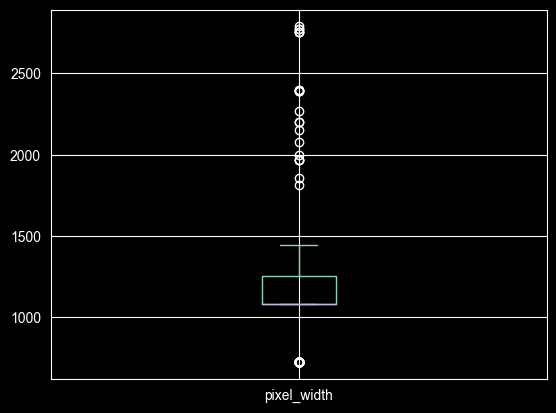

In [241]:
df['pixel_width'].plot(kind='box')

### fixing swapped pixels of phones

In [275]:
df[df['pixel_width'] > 1500]['model'][df[df['pixel_width'] > 1500]['model'].apply(lambda x: True if "Fold" not in str(x) else False )].index

Index([7, 14, 44, 72, 108, 130, 205, 343, 398, 757, 817, 826], dtype='int64')

In [268]:
df[df['pixel_width'] > 1500]['model'][df[df['pixel_width'] > 1500]['model'].str.contains('Fold')].index

Index([437, 506, 656, 669, 688, 713, 714, 751, 761, 843], dtype='int64')

In [289]:
x = df.loc[[7, 14, 44, 72, 108, 130, 205, 343, 398, 757, 817, 826],['pixel_width']].values
y = df.loc[[7, 14, 44, 72, 108, 130, 205, 343, 398, 757, 817, 826],['pixel_height']].values

In [290]:
df.loc[[7, 14, 44, 72, 108, 130, 205, 343, 398, 757, 817, 826],['pixel_width']] = y
df.loc[[7, 14, 44, 72, 108, 130, 205, 343, 398, 757, 817, 826],['pixel_height']] = x

In [294]:
df.loc[[7, 14, 44, 72, 108, 130, 205, 343, 398, 757, 817, 826],['pixel_width','pixel_height']]

,pixel_width,pixel_height
7,1272,2772
14,1080,2392
44,1272,2772
72,1268,2756
108,1080,2392
130,1188,2790
205,1080,2392
343,1268,2756
398,1268,2756
757,2440,2268


In [292]:
df.to_csv('./assets/final.csv',index=False)

In [293]:
df = pd.read_csv('./assets/final.csv')

### creating display_ppi feature

In [307]:
def calculate_ppi(row):
    width = row['pixel_width']
    height = row['pixel_height']
    diagonal_inches = row['display_size']
    pixel_diagonal = np.sqrt(width**2 + height**2)
    ppi = pixel_diagonal / diagonal_inches
    return ppi

df['display_ppi'] = calculate_ppi(df[['pixel_width','pixel_height','display_size']])

In [322]:
df.to_csv('./assets/final.csv',index=False)

In [323]:
df = pd.read_csv('./assets/final.csv')

In [317]:
x = df.pop('display_ppi')

In [319]:
df.insert(26,"display_ppi",x)

## os
- majority phones have Android os

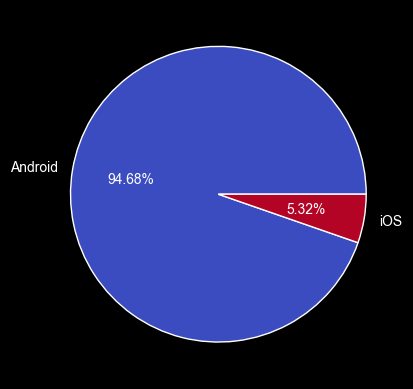

In [331]:
df['os'].value_counts().plot(kind='pie',autopct='%1.2f%%',cmap='coolwarm')
plt.savefig('./plots/univariate_analysis/os/pie_plot.png')

## is_memory_card_supported

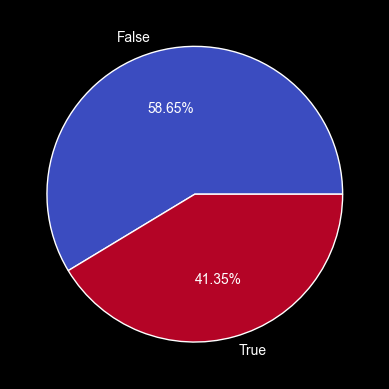

In [335]:
df['is_memory_card_supported'].value_counts().plot(kind='pie',autopct='%1.2f%%',cmap='coolwarm')
plt.savefig('./plots/univariate_analysis/is_memory_card_supported/pie_plot.png')

## max_card_gb

In [339]:
df['max_card_gb'].describe()

count     292.000000
mean     1372.054795
std       499.361404
min       256.000000
25%      1024.000000
50%      1024.000000
75%      2048.000000
max      2048.000000
Name: max_card_gb, dtype: float64

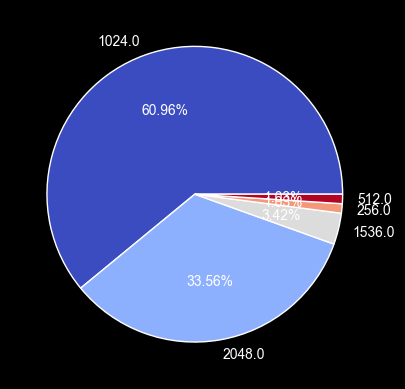

In [368]:
df['max_card_gb'].value_counts().plot(kind='pie',autopct='%1.2f%%',cmap='coolwarm')
plt.savefig('./plots/univariate_analysis/max_card_gb/pie_plot.png')

## primary_rear_mp
- mostly chinese phones have higher megapixel camera
- expensive phones with price > 100000 and >100MP camera are mostly `Samsung`

In [341]:
df['primary_rear_mp'].value_counts()

primary_rear_mp
50     647
48      54
200     51
64      51
108     37
13      29
32      20
12      10
8        1
2        1
180      1
Name: count, dtype: int64

In [346]:
df[df['primary_rear_mp'] > 100][df[df['primary_rear_mp'] > 100]['price'] >100000]

,pos,brand,model,price,rating,Dual Sim,3G,4G,5G,VoLTE,...,display_ppi,os,is_memory_card_supported,max_card_gb,primary_rear_mp,primary_front_mp,num_rear_cameras,num_front_cameras,processor_brand,processor_model
0,0,Samsung,Galaxy S25 Ultra,118998,4.15,True,True,True,True,True,...,498.011167,Android,False,NaN,200,12,4,1,Snapdragon,8 elite for galaxy
18,18,Samsung,Galaxy S26 Ultra 5G,120850,4.45,True,True,True,True,True,...,498.011167,Android,False,NaN,200,12,4,1,Snapdragon,8 elite gen 5 for galaxy
82,82,Samsung,Galaxy S26 Ultra,119990,4.60,True,True,True,True,True,...,498.011167,Android,False,NaN,200,12,4,1,Snapdragon,8 elite gen 5 for galaxy
122,122,Vivo,X300 Pro 5G,109999,4.35,True,True,True,True,True,...,452.867214,Android,False,NaN,200,50,3,1,Dimensity,9500
146,146,Oppo,Find X9 Pro 5G,109999,4.55,True,True,True,True,True,...,449.839644,Android,False,NaN,200,50,3,1,Dimensity,9500
159,159,Samsung,Galaxy S24 Ultra,119999,4.35,True,True,True,True,True,...,505.334861,Android,False,NaN,200,12,4,1,Snapdragon,8 gen3
192,192,Xiaomi,17 Ultra,139999,4.15,True,True,True,True,True,...,416.062296,Android,False,NaN,200,50,3,1,Snapdragon,8 elite gen 5
207,207,Samsung,Galaxy S26 Ultra,189999,4.10,True,True,True,True,True,...,498.011167,Android,False,NaN,200,12,4,1,Snapdragon,8 elite gen 5 for galaxy
270,270,Samsung,Galaxy S25 Ultra,120999,4.65,True,True,True,True,True,...,498.011167,Android,False,NaN,200,12,4,1,Snapdragon,8 elite for galaxy
437,437,Samsung,Galaxy Z Fold 7,174999,4.40,True,True,True,True,True,...,367.484694,Android,False,NaN,200,10,3,2,Snapdragon,8 elite for galaxy


## num_rear_camera
- majority phones which have 2 rear cameras are chinese

In [348]:
df['num_rear_cameras'].value_counts()

num_rear_cameras
2    476
3    356
1     52
4     18
Name: count, dtype: int64

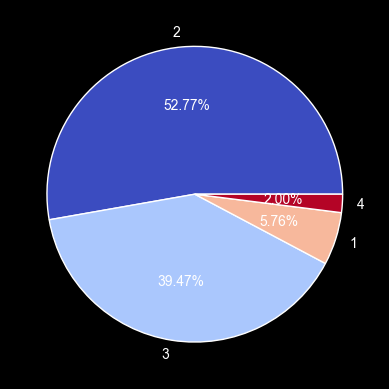

In [369]:
df['num_rear_cameras'].value_counts().plot(kind='pie',autopct='%1.2f%%',cmap='coolwarm')
plt.savefig('./plots/univariate_analysis/num_rear_cameras/pie_plot.png')

In [352]:
df[df['num_rear_cameras'] ==2][['brand']].value_counts()

brand   
Realme      97
Vivo        82
Oppo        47
Motorola    33
iQOO        33
Xiaomi      28
Poco        27
Samsung     20
Lava        18
OnePlus     17
Infinix     17
Tecno       16
Apple       14
Google       8
Ai+          5
Nothing      5
HMD          3
CMF          2
itel         2
Honor        1
Alcatel      1
Name: count, dtype: int64

## primary_front_mp
- mostly chines phones have higher MP rear camera

In [354]:
df['primary_front_mp'].value_counts()

primary_front_mp
32    178
8     158
16    148
50    134
13     80
12     70
5      65
20     36
10     16
18     12
42      4
44      1
Name: count, dtype: int64

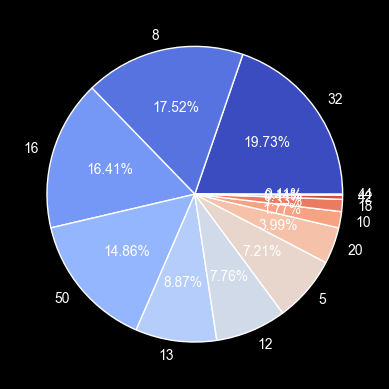

In [370]:
df['primary_front_mp'].value_counts().plot(kind='pie',autopct='%1.2f%%',cmap='coolwarm')
plt.savefig('./plots/univariate_analysis/primary_front_mp/pie_plot.png')

In [356]:
df[df['primary_front_mp'] ==32]['brand'].value_counts()

brand
Vivo        33
Realme      28
Motorola    26
iQOO        21
Oppo        20
OnePlus     15
Nothing     11
Xiaomi       8
Samsung      8
Infinix      4
Tecno        2
Ai+          1
Alcatel      1
Name: count, dtype: int64

## num_front_cameras
- majority of the phones have 1 front camera
- except few high-end phones all phones with 2 front cameras are flagship phones

In [357]:
df['num_front_cameras'].value_counts()

num_front_cameras
1    887
2     15
Name: count, dtype: int64

In [361]:
df[df['num_front_cameras'] == 2][['price']].describe()

,price
count,15.000000
mean,121891.133333
std,58252.821781
min,29990.000000
25%,72499.000000
50%,139499.000000
75%,157498.500000
max,216999.000000


## processor_brand
- majority phones have either Dimenisity or Snapdragon processor
- Google and Apple have their own in-house chips
- Realme, Vivo and Oppo are the three companies that uses more Dimensity processors than others
- Almost every company equally uses Snapdragon processor

In [362]:
df['processor_brand'].value_counts()

processor_brand
Dimensity     449
Snapdragon    320
Exynos         57
Apple          39
Unisoc         19
Google         18
Name: count, dtype: int64

In [364]:
df[df['processor_brand'] == 'Dimensity']['price'].describe()

count       449.000000
mean      24755.376392
std       15286.929023
min        9490.000000
25%       15499.000000
50%       19999.000000
75%       28494.000000
max      109999.000000
Name: price, dtype: float64

In [365]:
df[df['processor_brand'] == 'Dimensity']['brand'].value_counts()

brand
Realme      93
Vivo        80
Oppo        73
Samsung     30
Tecno       25
Infinix     24
Lava        21
Xiaomi      20
Motorola    18
iQOO        18
Poco        16
Nothing      7
OnePlus      6
CMF          4
Ai+          3
Acer         3
Wobble       3
itel         2
Alcatel      2
Honor        1
Name: count, dtype: int64

In [366]:
df[df['processor_brand'] == 'Snapdragon']['price'].describe()

count       320.000000
mean      41020.171875
std       32342.213362
min        9499.000000
25%       21999.000000
50%       30999.000000
75%       45999.000000
max      216999.000000
Name: price, dtype: float64

In [367]:
df[df['processor_brand'] == 'Snapdragon']['brand'].value_counts()

brand
Vivo        49
Realme      46
Samsung     40
Xiaomi      38
OnePlus     35
Motorola    31
iQOO        21
Poco        21
Oppo        17
Nothing     13
Honor        3
Infinix      2
HMD          2
Lava         2
Name: count, dtype: int64